In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse import linalg

# MATH 461 Unit 3 Project

**Group member**
- Ryan Hsiao
- Fanbo Feng
- Davis Li

## Numerical simulation

In [10]:
# Parameters 
z = 3
alpha = 1.94e-5 * 3600
# beta = 2.219
# beta = 1
# beta = 3.51
beta = 6
T_a = 293.15

# Two options (based on the data on the paper): 
# 1. Assume the pot emits the same amount of heat as the chamber, 171W.
# 2. Only use the chamber.
gamma = 171/(1.29*1004) * 3600 
# gamma = 1.09 * 3600

sd = 0.1

# The temperature of cook position record
cpt = []

In [11]:
### The following code is adapted and modified from the original MATLAB code provided by Professor Colin Macdonald in MATH 405 in UBC. ###

# Grid
J = 150
h = 3.0 / J
s = np.linspace(h, 3.0, J)
k = 0.1 * h
# k = 5 * h
xx, yy = np.meshgrid(s, s)
x = xx.flatten()
y = yy.flatten()

# Initial condition
u = np.full((J*J,), T_a)
ix = np.argmin(np.abs(s - 2.4))
iy = np.argmin(np.abs(s - 1.5))
cpt.append(u[iy * J + ix])

# Source term
# source = ((gamma/z) / (np.sqrt(2*np.pi*sd))) * np.exp(-((xx-2.8)**2 + (yy-1.5)**2) / (2*sd))
source = ((gamma/z) / (2*np.pi*sd**2)) * np.exp(-((xx-2.8)**2 + (yy-1.5)**2) / (2*sd**2))
source = source.flatten()

In [12]:
### The following code is adapted and modified from the original MATLAB code provided by Professor Colin Macdonald in MATH 405 in UBC. ###

# Matrix Construction (Backward Euler)
N = len(s)
e = np.ones(N)
L1d = sparse.spdiags([e, -2*e, e], [-1, 0, 1], N, N).tocsr()
L1d[0, 0] = -2
L1d[0, 1] = 2
L1d[-1, -1] = -2
L1d[-1, -2] = 2
L1d = (1 / h**2) * L1d
I1d = sparse.eye(N)

L = sparse.kron(I1d, L1d) + sparse.kron(L1d, I1d)
I = sparse.eye(L.shape[0])

A = I - k*alpha*L + k*beta*I 

In [13]:
### The following code is adapted and modified from the original MATLAB code provided by Professor Colin Macdonald in MATH 405 in UBC. ###

# Time-stepping
Tf = 12
numsteps = int(np.ceil(Tf / k))
t = 0

In [14]:
### The following code is adapted and modified from the original MATLAB code provided by Professor Colin Macdonald in MATH 405 in UBC. ###

# Times we want to capture
target_times = np.linspace(0, Tf, 4)
# target_times = [0, 0.3, 1, Tf]
snapshots = {}

next_target_idx = 0

for n in range(numsteps + 1):       
    for target in target_times:
        if np.isclose(t, target, atol=k/2):
            snapshots[target] = u.reshape(xx.shape)
    
    if n < numsteps:
        b = u + k*source + k*beta*T_a
        # b = u + k*source
        u = linalg.spsolve(A, b)

        # Make sure the heat does not exceed 1000
        # u = np.clip(u, T_a, 1000)

        cpt.append(u[iy * J + ix])

        t += k

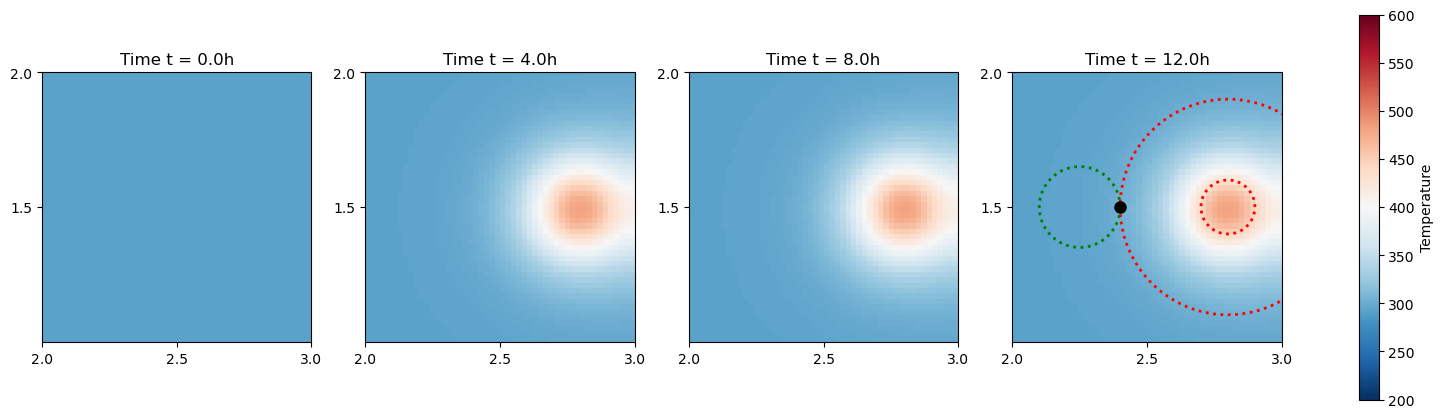

In [15]:
### The following code is adapted and modified from the original MATLAB code provided by Professor Colin Macdonald in MATH 405 in UBC. ###

# Plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot the subplots
for i, target in enumerate(target_times):
    im = axes[i].imshow(snapshots[target], extent=[0, 3, 0, 3], origin='lower', cmap='RdBu_r', vmin=200, vmax=600) # vmax = 800
    axes[i].set_title(f'Time t = {target}h')
    axes[i].set_xticks([0, 1.5, 2, 2.5, 3])
    axes[i].set_yticks([0, 1.5, 2, 2.5, 3])
    axes[i].set_xlim(2, 3)
    axes[i].set_ylim(1, 2)

fig.colorbar(im, ax=axes.ravel().tolist(), label='Temperature')
# plt.suptitle(f'2D Heat Diffusion (Backward Euler) with beta = {beta}', fontsize=16)

# Regular standing position away from the stove
theta = np.linspace(0, 2*np.pi, 100)
x_circle_1 = 2.8 + 0.4 * np.cos(theta)
y_circle_1 = 1.5 + 0.4 * np.sin(theta)
plt.plot(x_circle_1, y_circle_1, color='red', linestyle=':', linewidth=2, label='Target')

# Size of the stove
x_circle_1 = 2.8 + 0.1 * np.cos(theta)
y_circle_1 = 1.5 + 0.1 * np.sin(theta)
plt.plot(x_circle_1, y_circle_1, color='red', linestyle=':', linewidth=2, label='Target')

# Size of the chef
x_circle_1 = 2.25 + 0.15 * np.cos(theta)
y_circle_1 = 1.5 + 0.15 * np.sin(theta)
plt.plot(x_circle_1, y_circle_1, color='green', linestyle=':', linewidth=2, label='cook position')

# Consider the chef as a point
plt.plot(2.4, 1.5, color='black', marker='o', markersize=8, label='cook position')

# Set display area
plt.xlim(2, 3)
plt.ylim(1, 2)
plt.show()

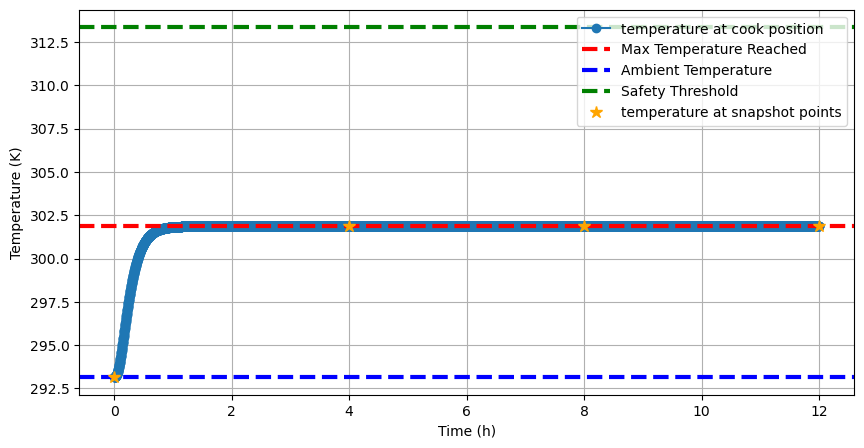

In [16]:
temp = np.array(cpt)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(np.arange(len(temp)) * k, temp, marker='o', label='temperature at cook position')

plt.axhline(max(temp), color='red', linestyle='--', linewidth=3, label='Max Temperature Reached')
plt.axhline(T_a, color='blue', linestyle='--', linewidth=3, label='Ambient Temperature')
plt.axhline(313.35, color='green', linestyle='--', linewidth=3, label='Safety Threshold')
plt.plot(target_times, [snapshots[target][iy, ix] for target in target_times], '*', markersize=9, color='orange', label='temperature at snapshot points')

# plt.title(f'Temperature at Cook Position Over Time with beta = {beta}')
plt.xlabel('Time (h)')
plt.ylabel('Temperature (K)')
plt.grid()
plt.legend()
plt.show()

## Steady state

Set $u_t=0$

## Numerical stability analysis

In above simulation, we use the mothod of Method of Line (MOL) with the scheme of backward Euler in time and central differecne in space. We pick backward Euler as it is an implicit method with unconditionally stability. However, the numerical stability may be affected by the source term ($S(x, y)$) and the sink term ($L(u)$), we can perform von Neumann stability analysis here to check the stability of the PDE.

From the govering equation, 

$$
u_t = \alpha (u_{xx} + u_{yy}) + S(x, y) - \beta(u - T_a) \ , 
$$

we can discretize it with backward Euler and get the following:

$$
\frac{u^{n+1}_{i, j} - u^n_{i, j}}{\Delta t} = \alpha \left( \frac{u^{n+1}_{i-1, j} - 2u^{n+1}_{i, j} + u^{n+1}_{i+1, j}}{\Delta x^2} + \frac{u^{n+1}_{i, j-1} - 2u^{n+1}_{i, j} + u^{n+1}_{i, j+1}}{\Delta y^2} \right) + S - \beta u^{n+1}_{i, j} + \beta T_a \ .
$$

Since we are using a square domain, we set $\Delta x = \Delta y = h$ and $\Delta t = k$.


By rearranging the function and dropping terms that do not depend on $u$, we get 

$$
u^n_{i, j} = u^{n+1}_{i, j} - r \left( u^{n+1}_{i-1, j} - 2u^{n+1}_{i, j} + u^{n+1}_{i+1, j} + u^{n+1}_{i, j-1} - 2u^{n+1}_{i, j} + u^{n+1}_{i, j+1} \right) - k\beta u^{n+1}_{i, j} \ .
$$

where $r = \dfrac{\alpha k}{h^2}$.

Here, we use an Ansatz method such that $u^n_{i, j} = g(\xi_m, \xi_n)\exp(i\xi_m h m + i\xi_n h n)$, where $\xi_m$ and $\xi_n$ are wavenumbers and $g(\xi_m, \xi_n)$ is the amplication factor of the wavenumber. Then, we can substitude this into the discritized equation above and get

$$
\begin{aligned}
g(\xi_m, \xi_n)^n \exp(i\xi_m hm + i\xi_n hn) = g(\xi_m, \xi_n)^{n+1} \exp(i\xi_m hm + i\xi_n hn) &- rg(\xi_m, \xi_n)^{n+1}(\exp(i\xi_m h(m-1) + i\xi_n hn) - 2\exp(i\xi_m hm + i\xi_n hn) + \exp(i\xi_m h(m+1) + i\xi_n hn)\\
&+ \exp(i\xi_m hm + i\xi_n h(n-1)) - 2\exp(i\xi_m hm + i\xi_n hn) + \exp(i\xi_m hm + i\xi_n h(n+1))) \\
& + k\beta g(\xi_m, \xi_n)^{n+1} \exp(i\xi_m hm + i\xi_n hn) \\
\end{aligned}
$$

Divide both sides by $g(\xi_m, \xi_n)^n \exp(i\xi_m hm + i\xi_n hn)$, we get

$$
\begin{aligned}
1 &= g(\xi_m, \xi_n) - rg(\xi_m, \xi_n)(\exp(-i\xi_m h) - 2 + \exp(i\xi_m h) + \exp(-i\xi_n h) - 2 + \exp(i\xi_n h)) + k\beta g(\xi_m, \xi_n) \\
&= g(\xi_m, \xi_n) (1 - r(\exp(-i\xi_m h) - 2 + \exp(i\xi_m h) + \exp(-i\xi_n h) - 2 + \exp(i\xi_n h)) + k\beta)
\end{aligned}
$$

From Euler's equation $exp(i\theta) = \cos\theta + i\sin\theta$ and $exp(-i\theta) = \cos\theta - i\sin\theta$, we get 

$$
\begin{aligned}
& 1 = g(\xi_m, \xi_n) (1 - r(2\cos(\xi_m h) - 2 + 2\cos(\xi_n h) - 2) + k\beta) \\
\implies & g(\xi_m, \xi_n) = \frac{1}{1 - r(2\cos(\xi_m h) - 2 + 2\cos(\xi_n h) - 2) + k\beta}
\end{aligned}
$$

For this to be numerical stable, we need $|g(\xi_m, \xi_n)| \le 1$. In other words, we need $1 - r(2\cos(\xi_m h) - 2 + 2\cos(\xi_n h) - 2) + k\beta \ge 1$. For simplicity we let $D = 1 - r(2\cos(\xi_m h) - 2 + 2\cos(\xi_n h) - 2) + k\beta$. 

Now, we consider only the $\cos(\xi_m h)$ term:

$$
\begin{aligned}
-1 \le \cos&(\xi_m h) \le 1 , \\ 
-2 \le 2\cos&(\xi_m h) \le 2 , \\
-4 \le \cos&(\xi_m h) - 2 \le 0 .
\end{aligned}
$$

It is the same for $\cos(\xi_n h)$ that it ranges between $[-4,0]$. Next, we know that $r = \dfrac{\alpha k}{h^2} > 0$ as $\alpha, k, h > 0$. Finally, we also get $k\beta>0$ as $k, \beta>0$. Hence, combining these terms, we get two cases. If both $\cos(\xi_m h)$ and $\cos(\xi_n h)$ is at its lowest point $-4$, then 

$$
D = 1 - r(-4 - 4) + k\beta = 1 + 8r + k\beta \ge 1
$$

If both $\cos(\xi_m h)$ and $\cos(\xi_n h)$ is at its higherst point $0$, then 

$$
D = 1 - r(0) + k\beta = 1 + k\beta \ge 1
$$

Hence, we get $D$ is always greater to equal to 1 as required. Therefore, $|g(\xi_m, \xi_n)| = \left| \dfrac{1}{D} \right| \le 1$ as required.

The backward Euler scheme is unconditionally stable for all wave numbers $\xi_m$ and $\xi_n$.

## Numerical consistency 

To find numerical consistency, we look at the local truncation errors in both time and space.

In time, as it is first order backward Euler, we get the error to be $O(k)$. In space, we know it is in central difference scheme, we have it is $O(h^2)$ in $x$ and $y$ such that $\Delta x = \Delta y = h$. On the other hand, we have the function $L(u)$ is linear and do not involve spatial derivatives in it, therefore, the term $\beta u$ do not introduce spatial truncation error to the system. 

Hence, we have the local truncation error (LTE) $\tau = O(k) + O(h^2)$. We know the PDE is consistent as 

$$
\begin{align*}
\lim_{k\rightarrow 0 \ ; h \rightarrow 0}(O(k) + O(h^2)) = 0 \ .
\end{align*}
$$

## Numerical convergence

By Lax equivalence theorem, we know consistency and stability implies convergence. Hence, we know the numerical solution converges.